<a href="https://colab.research.google.com/github/Chosencodes/Medical-Imaging-Projects/blob/main/Pneumonia_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"otaborchosen","key":"58a93c29dd2166edb0090f24b2d49e9f"}'}

In [3]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [11]:
!pip install pydicom

In [5]:
import numpy as np
import pandas as pd
import cv2
import pydicom
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

In [9]:
!kaggle competitions download -c rsna-pneumonia-detection-challenge

100% 3.66G/3.66G [02:17<00:00, 28.6MB/s]



In [10]:
!unzip rsna-pneumonia-detection-challenge.zip

Streaming output truncated to the last 5000 lines.
  inflating: stage_2_train_images/d5252a78-3ea1-48e9-9ffb-e7535be3ce80.dcm  
  inflating: stage_2_train_images/d525eafb-8908-45fd-a942-48d07c435487.dcm  
  inflating: stage_2_train_images/d5265640-17db-4880-866d-d2952e32941c.dcm  
  inflating: stage_2_train_images/d5277276-f8f8-40e9-b8e1-791cf5d96ac0.dcm  
  inflating: stage_2_train_images/d528d9e9-647a-4e2e-a16c-bd5e32a5bbf5.dcm  
  inflating: stage_2_train_images/d5293a3e-f050-4b98-8bbf-1f40e25bced5.dcm  
  inflating: stage_2_train_images/d52cbb5a-1d0a-457d-8c72-0f7aeec21ca7.dcm  
  inflating: stage_2_train_images/d52ce67b-be7c-4349-8dc4-38562928d208.dcm  
  inflating: stage_2_train_images/d535a3c8-c4a4-4856-b5cd-17f6332eac8b.dcm  
  inflating: stage_2_train_images/d5360dc4-6bea-4a7b-bc49-5b2547ad7877.dcm  
  inflating: stage_2_train_images/d5364bc1-bc2a-4bd0-a1bd-0cfb5a369ccc.dcm  
  inflating: stage_2_train_images/d539e101-5662-445c-9f6a-381e674f0aed.dcm  
  inflating: stage_2_trai

In [38]:
import torch
import torchvision
from torchvision import transforms
import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger

In [39]:
labels = pd.read_csv("/content/stage_2_train_labels.csv")

In [40]:
labels.head(6)

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1


In [42]:
labels = labels.drop_duplicates('patientId')

In [43]:
labels.head(6)

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1
6,00569f44-917d-4c86-a842-81832af98c30,NaN,NaN,NaN,NaN,0


In [53]:
ROOT_PATH = Path("/content/stage_2_train_images/")
SAVE_PATH = Path("Processed/")

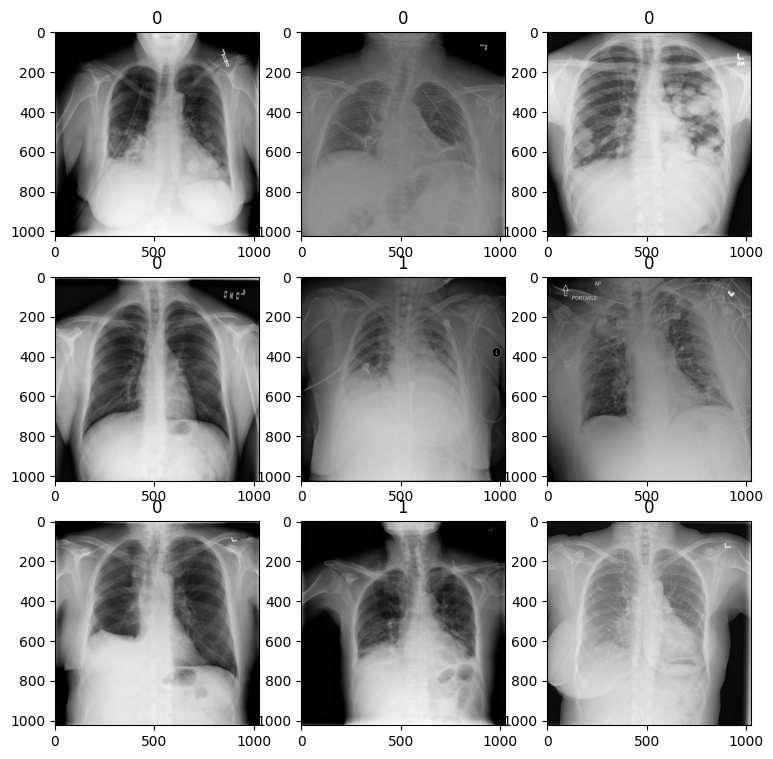

In [55]:
fig,axis = plt.subplots(3,3, figsize=(9,9))
c = 0

for i in range(3):
  for j in range(3):
    patient_id = labels.patientId.iloc[c]
    dcm_path = ROOT_PATH/patient_id
    dcm_path = dcm_path.with_suffix('.dcm')
    dcm = pydicom.dcmread(dcm_path).pixel_array
    label = labels.Target.iloc[c]



    axis[i][j].imshow(dcm,cmap='gray')
    axis[i][j].set_title(label)
    c+=1

In [68]:
sums = 0
sums_squared = 0

for c,patient_id in enumerate(tqdm(labels.patientId)):
  dcm_path = ROOT_PATH/patient_id
  dcm_path = dcm_path.with_suffix('.dcm')
  dcm = pydicom.dcmread(dcm_path).pixel_array / 255
  label = labels.Target.iloc[c]

  dcm_array = cv2.resize(dcm,(224,224)).astype(np.float16)

  train_or_val = "train" if c < 24000 else "val"

  current_save_path = SAVE_PATH/train_or_val/str(label)
  current_save_path.mkdir(parents=True,exist_ok=True)
  np.save(current_save_path/patient_id,dcm_array)

  normalizer = dcm_array.shape[0] * dcm_array.shape[1]
  if train_or_val == "train":
    sums+= np.sum(dcm_array) / normalizer
    sums_squared += (np.power(dcm_array,2).sum()) / normalizer

mean = sums / 24000
std =np.sqrt(sums_squared / 24000 - (mean**2))



  0%|          | 0/26684 [00:00<?, ?it/s]

In [69]:
print(f"Mean: {mean}")
print(f"STD: {std}")

Mean: 0.0853271484375
STD: 0.2340087890625


In [ ]:
def load_file(path):
  return np.load(load_file).astype(np.float32)

In [70]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.0853,0.2340),
    transforms.RandomAffine(degrees=(-5,5),translate=(0,0.05),scale=(0.9,1.1)),
    transforms.RandomResizedCrop(size=(224,224),scale=(0.35,1))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.0853,0.2340)
])

In [74]:
train_data = torchvision.datasets.DatasetFolder("Processed/train",loader=load_file,extensions="npy",transform=train_transform)
val_data = torchvision.datasets.DatasetFolder("Processed/val",loader=load_file,extensions="npy",transform=val_transform)

In [75]:
train_loader = torch.utils.data.DataLoader(train_data,batch_size=64,num_workers=4,shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data,batch_size=64,num_workers=4,shuffle=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
